TASK 4 : SPAM SMS DETECTION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

In [7]:
df.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


EXPLORE DATASET STRUCTURE

In [8]:
# Check column names
print("Column Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check dataset info
print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data Types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB

Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


 SELECT & RENAME COLUMNS

In [9]:
# Select only label and message columns
df = df[['v1', 'v2']].copy()

# Rename columns for clarity
df.columns = ['label', 'message']

print("✅ Columns selected and renamed!")
print(df.head())

✅ Columns selected and renamed!
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


CHECK CLASS DISTRIBUTION

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class Distribution (%):
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


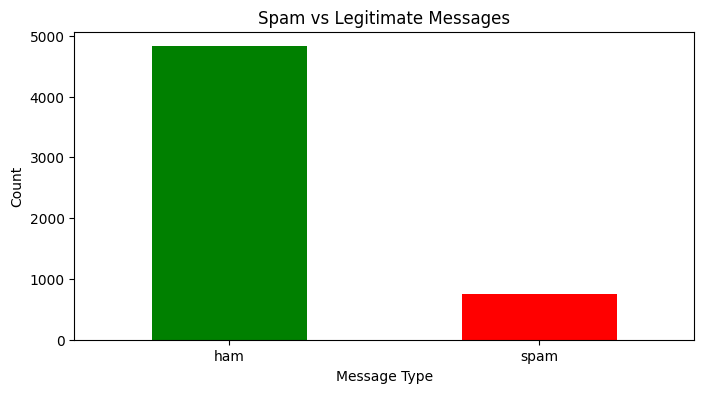

In [10]:
# Count spam vs ham
print("Class Distribution:")
print(df['label'].value_counts())

# Percentage distribution
print("\nClass Distribution (%):")
print(df['label'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(8, 4))
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Spam vs Legitimate Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

REMOVE DUPLICATES

In [11]:
# Check for duplicates
print(f"Duplicate messages: {df.duplicated(subset=['message']).sum()}")

# Remove duplicates
df = df.drop_duplicates(subset=['message']).reset_index(drop=True)

print(f"✅ Duplicates removed!")
print(f"New dataset size: {len(df)}")

Duplicate messages: 403
✅ Duplicates removed!
New dataset size: 5169


CONVERT LABELS TO BINARY

✅ Labels converted!
Label mapping: 0 = Legitimate (ham), 1 = Spam

Final distribution:
label
0    4516
1     653
Name: count, dtype: int64


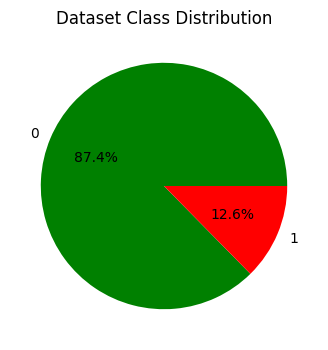

In [12]:
# Convert ham/spam to 0/1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print("✅ Labels converted!")
print(f"Label mapping: 0 = Legitimate (ham), 1 = Spam")
print(f"\nFinal distribution:")
print(df['label'].value_counts())

# Visualize
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Dataset Class Distribution')
plt.ylabel('')
plt.show()

DATA SUMMARY

In [13]:
# Display sample messages
print("Sample Legitimate Messages:")
print("-" * 70)
legit_samples = df[df['label'] == 0]['message'].head(3)
for i, msg in enumerate(legit_samples, 1):
    print(f"{i}. {msg}\n")

print("\nSample Spam Messages:")
print("-" * 70)
spam_samples = df[df['label'] == 1]['message'].head(3)
for i, msg in enumerate(spam_samples, 1):
    print(f"{i}. {msg}\n")

Sample Legitimate Messages:
----------------------------------------------------------------------
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...


Sample Spam Messages:
----------------------------------------------------------------------
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv

3. WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.



FEATURE EXTRACTION - TF-IDF

In [14]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=3000,      # Use top 3000 features
    stop_words='english',   # Remove common words
    lowercase=True,
    ngram_range=(1, 2),     # Unigrams and bigrams
    min_df=2,              # Min document frequency
    max_df=0.8             # Max document frequency
)

# Fit and transform text data
X = tfidf.fit_transform(df['message'])

print("✅ TF-IDF Vectorization complete!")
print(f"Feature Matrix Shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of messages: {X.shape[0]}")

# Show some feature names
feature_names = tfidf.get_feature_names_out()
print(f"\nFirst 20 features: {feature_names[:20]}")

✅ TF-IDF Vectorization complete!
Feature Matrix Shape: (5169, 3000)
Number of features: 3000
Number of messages: 5169

First 20 features: ['00' '000' '000 bonus' '000 cash' '02' '02 06' '0207' '03' '03 2nd' '04'
 '05' '06' '06 03' '07xxxxxxxxx' '0800' '0800 542' '08000839402'
 '08000839402 call2optout' '08000930705' '08000930705 delivery']


 EXTRACT TARGET VARIABLE

In [15]:
# Extract target variable (labels)
y = df['label'].values

print(f"Target variable shape: {y.shape}")
print(f"Spam (1): {(y == 1).sum()}")
print(f"Legitimate (0): {(y == 0).sum()}")

Target variable shape: (5169,)
Spam (1): 653
Legitimate (0): 4516


TRAIN-TEST SPLIT

In [16]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% for testing
    random_state=42,         # For reproducibility
    stratify=y              # Maintain class distribution
)

print("✅ Train-Test Split Complete!")
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

print(f"\nTraining set class distribution:")
print(f"  Legitimate: {(y_train == 0).sum()}")
print(f"  Spam: {(y_train == 1).sum()}")

print(f"\nTest set class distribution:")
print(f"  Legitimate: {(y_test == 0).sum()}")
print(f"  Spam: {(y_test == 1).sum()}")

✅ Train-Test Split Complete!

Training set size: 4135
Test set size: 1034

Training set class distribution:
  Legitimate: 3613
  Spam: 522

Test set class distribution:
  Legitimate: 903
  Spam: 131


 TRAIN NAIVE BAYES MODEL

In [17]:
# Train Naive Bayes
print("Training Naive Bayes...")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions
nb_pred = nb_model.predict(X_test)
nb_pred_proba = nb_model.predict_proba(X_test)

# Evaluate
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print("✅ Naive Bayes Model Trained!")
print(f"\nNaive Bayes Metrics:")
print(f"  Accuracy:  {nb_accuracy:.4f}")
print(f"  Precision: {nb_precision:.4f}")
print(f"  Recall:    {nb_recall:.4f}")
print(f"  F1-Score:  {nb_f1:.4f}")

# Confusion Matrix
nb_cm = confusion_matrix(y_test, nb_pred)
print(f"\nConfusion Matrix:")
print(nb_cm)

Training Naive Bayes...
✅ Naive Bayes Model Trained!

Naive Bayes Metrics:
  Accuracy:  0.9749
  Precision: 0.9907
  Recall:    0.8092
  F1-Score:  0.8908

Confusion Matrix:
[[902   1]
 [ 25 106]]


TRAIN LOGISTIC REGRESSION MODEL

In [18]:
# Train Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("✅ Logistic Regression Model Trained!")
print(f"\nLogistic Regression Metrics:")
print(f"  Accuracy:  {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall:    {lr_recall:.4f}")
print(f"  F1-Score:  {lr_f1:.4f}")

# Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_pred)
print(f"\nConfusion Matrix:")
print(lr_cm)

Training Logistic Regression...
✅ Logistic Regression Model Trained!

Logistic Regression Metrics:
  Accuracy:  0.9545
  Precision: 0.9884
  Recall:    0.6489
  F1-Score:  0.7834

Confusion Matrix:
[[902   1]
 [ 46  85]]


TRAIN SVM MODEL

In [19]:
# Train Support Vector Machine
print("Training Support Vector Machine (SVM)...")
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
svm_pred = svm_model.predict(X_test)
svm_pred_proba = svm_model.predict_proba(X_test)

# Evaluate
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("✅ SVM Model Trained!")
print(f"\nSVM Metrics:")
print(f"  Accuracy:  {svm_accuracy:.4f}")
print(f"  Precision: {svm_precision:.4f}")
print(f"  Recall:    {svm_recall:.4f}")
print(f"  F1-Score:  {svm_f1:.4f}")

# Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_pred)
print(f"\nConfusion Matrix:")
print(svm_cm)

Training Support Vector Machine (SVM)...
✅ SVM Model Trained!

SVM Metrics:
  Accuracy:  0.9797
  Precision: 0.9825
  Recall:    0.8550
  F1-Score:  0.9143

Confusion Matrix:
[[901   2]
 [ 19 112]]


DETAILED CLASSIFICATION REPORT

In [20]:
# Detailed report for all models

print("="*70)
print("NAIVE BAYES - DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, nb_pred, target_names=['Legitimate', 'Spam']))

print("\n" + "="*70)
print("LOGISTIC REGRESSION - DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, lr_pred, target_names=['Legitimate', 'Spam']))

print("\n" + "="*70)
print("SUPPORT VECTOR MACHINE - DETAILED CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_test, svm_pred, target_names=['Legitimate', 'Spam']))

NAIVE BAYES - DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.99       903
        Spam       0.99      0.81      0.89       131

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.94      1034
weighted avg       0.98      0.97      0.97      1034


LOGISTIC REGRESSION - DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.97       903
        Spam       0.99      0.65      0.78       131

    accuracy                           0.95      1034
   macro avg       0.97      0.82      0.88      1034
weighted avg       0.96      0.95      0.95      1034


SUPPORT VECTOR MACHINE - DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99       903
        Spam       0.98      0.85      0.91       131

    accuracy              

CONFUSION MATRICES VISUALIZATION

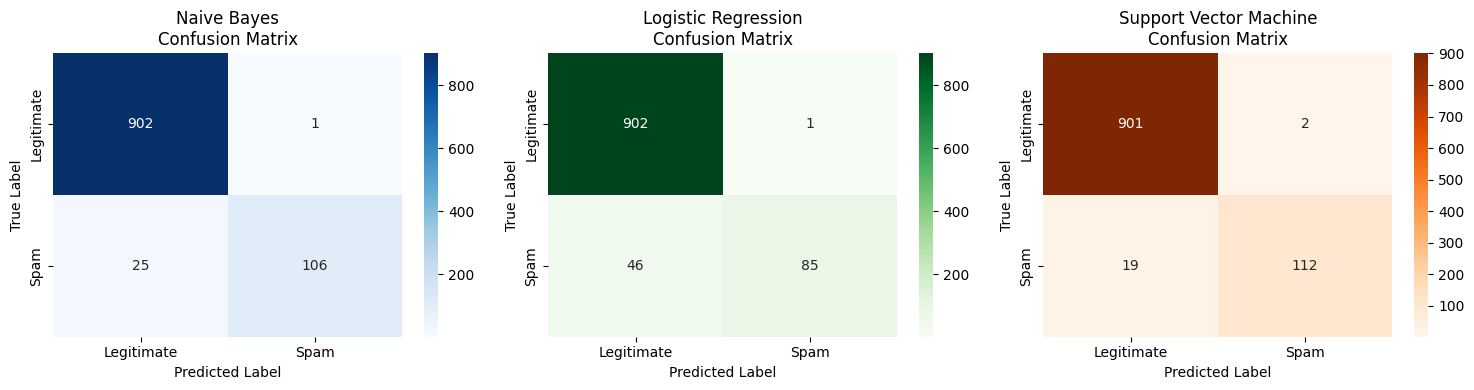

In [21]:
# Plot confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Naive Bayes
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Spam'],
            yticklabels=['Legitimate', 'Spam'])
axes[0].set_title('Naive Bayes\nConfusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Logistic Regression
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Legitimate', 'Spam'],
            yticklabels=['Legitimate', 'Spam'])
axes[1].set_title('Logistic Regression\nConfusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# SVM
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Legitimate', 'Spam'],
            yticklabels=['Legitimate', 'Spam'])
axes[2].set_title('Support Vector Machine\nConfusion Matrix')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

 MODELS COMPARISON

MODEL COMPARISON
                     Accuracy  Precision    Recall  F1-Score
Naive Bayes          0.974855   0.990654  0.809160  0.890756
Logistic Regression  0.954545   0.988372  0.648855  0.783410
SVM                  0.979691   0.982456  0.854962  0.914286


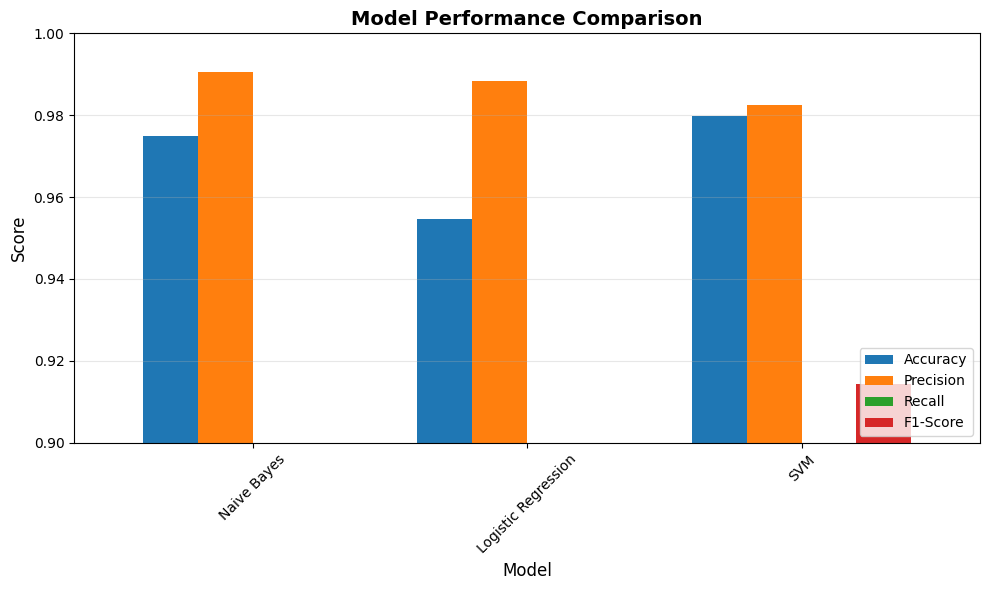

In [22]:
# Compare all models
results = {
    'Naive Bayes': {
        'Accuracy': nb_accuracy,
        'Precision': nb_precision,
        'Recall': nb_recall,
        'F1-Score': nb_f1
    },
    'Logistic Regression': {
        'Accuracy': lr_accuracy,
        'Precision': lr_precision,
        'Recall': lr_recall,
        'F1-Score': lr_f1
    },
    'SVM': {
        'Accuracy': svm_accuracy,
        'Precision': svm_precision,
        'Recall': svm_recall,
        'F1-Score': svm_f1
    }
}

# Create comparison dataframe
results_df = pd.DataFrame(results).T
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df.to_string())

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim([0.9, 1.0])
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ROC-AUC CURVES

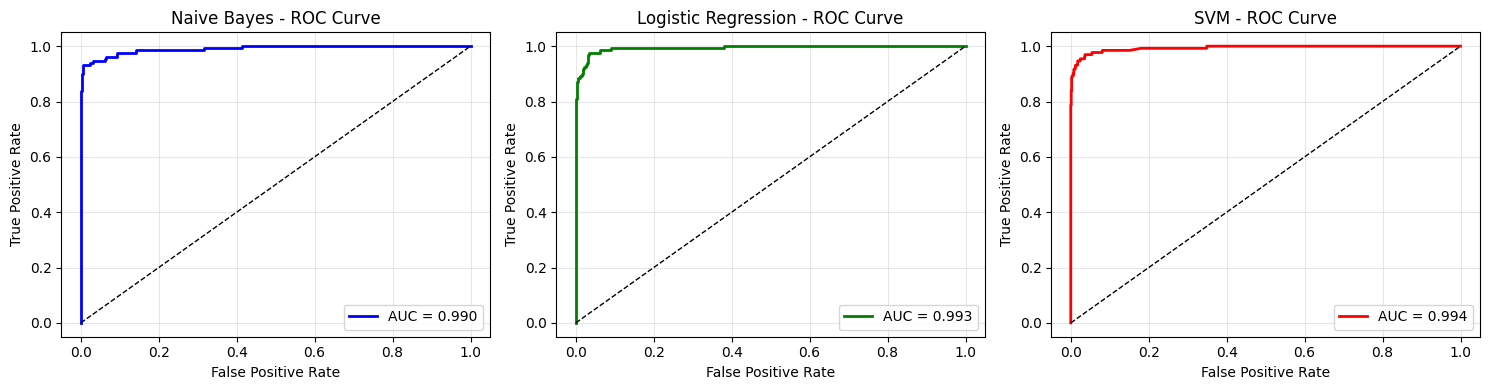

Naive Bayes AUC: 0.9901
Logistic Regression AUC: 0.9931
SVM AUC: 0.9935


In [23]:
# Calculate ROC-AUC for each model
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Naive Bayes
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_pred_proba[:, 1])
nb_auc = auc(nb_fpr, nb_tpr)
axes[0].plot(nb_fpr, nb_tpr, linewidth=2, color='blue', label=f'AUC = {nb_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Naive Bayes - ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba[:, 1])
lr_auc = auc(lr_fpr, lr_tpr)
axes[1].plot(lr_fpr, lr_tpr, linewidth=2, color='green', label=f'AUC = {lr_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Logistic Regression - ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# SVM
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_pred_proba[:, 1])
svm_auc = auc(svm_fpr, svm_tpr)
axes[2].plot(svm_fpr, svm_tpr, linewidth=2, color='red', label=f'AUC = {svm_auc:.3f}')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('SVM - ROC Curve')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Naive Bayes AUC: {nb_auc:.4f}")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"SVM AUC: {svm_auc:.4f}")

 BEST MODEL SELECTION

In [24]:
# Find best model based on F1-Score
best_f1_model = max(results.keys(), key=lambda x: results[x]['F1-Score'])
best_f1_score = results[best_f1_model]['F1-Score']

print("="*70)
print(f"BEST MODEL: {best_f1_model}")
print("="*70)
print(f"F1-Score: {best_f1_score:.4f}")
print(f"Accuracy: {results[best_f1_model]['Accuracy']:.4f}")
print(f"Precision: {results[best_f1_model]['Precision']:.4f}")
print(f"Recall: {results[best_f1_model]['Recall']:.4f}")

# Assign best model
if best_f1_model == 'Naive Bayes':
    best_model = nb_model
elif best_f1_model == 'Logistic Regression':
    best_model = lr_model
else:
    best_model = svm_model

BEST MODEL: SVM
F1-Score: 0.9143
Accuracy: 0.9797
Precision: 0.9825
Recall: 0.8550


PREDICT ON NEW MESSAGES

In [25]:
# Test with sample messages
test_messages = [
    "You have won a free iPhone! Click here to claim your prize NOW!",
    "Hey, how are you doing today? Let me know when you're free to meet.",
    "URGENT! Your account has been suspended. Verify your details immediately!",
    "Hi there, did you finish the project? Let me know your thoughts.",
    "Congratulations! You're selected to win a luxury car. Reply with your details!",
    "Mom, I'll be home late. Need anything from the store?"
]

print("="*80)
print("TESTING WITH SAMPLE MESSAGES (Using Best Model: " + best_f1_model + ")")
print("="*80)

# Vectorize and predict
test_vectors = tfidf.transform(test_messages)
test_predictions = best_model.predict(test_vectors)
test_probabilities = best_model.predict_proba(test_vectors)

# Display results
for i, msg in enumerate(test_messages):
    prediction = "🚨 SPAM" if test_predictions[i] == 1 else "✓ LEGITIMATE"
    spam_prob = test_probabilities[i][1] * 100

    print(f"\nMessage {i+1}:")
    print(f"Text: \"{msg}\"")
    print(f"Prediction: {prediction}")
    print(f"Spam Confidence: {spam_prob:.2f}%")
    print("-" * 80)

TESTING WITH SAMPLE MESSAGES (Using Best Model: SVM)

Message 1:
Text: "You have won a free iPhone! Click here to claim your prize NOW!"
Prediction: 🚨 SPAM
Spam Confidence: 100.00%
--------------------------------------------------------------------------------

Message 2:
Text: "Hey, how are you doing today? Let me know when you're free to meet."
Prediction: ✓ LEGITIMATE
Spam Confidence: 0.06%
--------------------------------------------------------------------------------

Message 3:
Text: "URGENT! Your account has been suspended. Verify your details immediately!"
Prediction: ✓ LEGITIMATE
Spam Confidence: 43.12%
--------------------------------------------------------------------------------

Message 4:
Text: "Hi there, did you finish the project? Let me know your thoughts."
Prediction: ✓ LEGITIMATE
Spam Confidence: 0.03%
--------------------------------------------------------------------------------

Message 5:
Text: "Congratulations! You're selected to win a luxury car. Reply with

 SINGLE MESSAGE PREDICTION FUNCTION

In [26]:
# Create a reusable function for predictions
def predict_spam(message, model, vectorizer):
    """
    Predict if a message is spam or legitimate

    Args:
        message (str): The SMS message to classify
        model: The trained ML model
        vectorizer: The TF-IDF vectorizer

    Returns:
        dict: Contains prediction and confidence
    """
    # Vectorize the message
    message_vector = vectorizer.transform([message])

    # Get prediction
    prediction = model.predict(message_vector)[0]

    # Get probability
    probability = model.predict_proba(message_vector)[0]

    result = {
        'message': message,
        'is_spam': prediction == 1,
        'spam_probability': probability[1],
        'legitimate_probability': probability[0]
    }

    return result

# Test the function
print("Testing Prediction Function:")
print("-" * 70)

test_msg = "Free money today! Click here!!!"
result = predict_spam(test_msg, best_model, tfidf)

print(f"Message: {result['message']}")
print(f"Classification: {'SPAM 🚨' if result['is_spam'] else 'LEGITIMATE ✓'}")
print(f"Spam Probability: {result['spam_probability']:.2%}")
print(f"Legitimate Probability: {result['legitimate_probability']:.2%}")

Testing Prediction Function:
----------------------------------------------------------------------
Message: Free money today! Click here!!!
Classification: LEGITIMATE ✓
Spam Probability: 6.13%
Legitimate Probability: 93.87%


 BATCH PREDICTION FUNCTION

In [27]:
# Function to predict multiple messages at once
def predict_spam_batch(messages, model, vectorizer):
    """
    Predict multiple messages at once

    Args:
        messages (list): List of SMS messages
        model: The trained ML model
        vectorizer: The TF-IDF vectorizer

    Returns:
        DataFrame: Results for all messages
    """
    # Vectorize all messages
    message_vectors = vectorizer.transform(messages)

    # Get predictions
    predictions = model.predict(message_vectors)
    probabilities = model.predict_proba(message_vectors)

    # Create results dataframe
    results_list = []
    for msg, pred, probs in zip(messages, predictions, probabilities):
        results_list.append({
            'Message': msg,
            'Prediction': 'SPAM' if pred == 1 else 'LEGITIMATE',
            'Spam_Confidence': probs[1],
            'Legitimate_Confidence': probs[0]
        })

    return pd.DataFrame(results_list)

# Test batch prediction
batch_messages = [
    "Call me later",
    "Free gift cards now!",
    "What time is the meeting?",
    "You've won a prize!"
]

batch_results = predict_spam_batch(batch_messages, best_model, tfidf)
print("Batch Prediction Results:")
print(batch_results.to_string())

Batch Prediction Results:
                     Message  Prediction  Spam_Confidence  Legitimate_Confidence
0              Call me later  LEGITIMATE         0.000056               0.999944
1       Free gift cards now!  LEGITIMATE         0.548729               0.451271
2  What time is the meeting?  LEGITIMATE         0.005156               0.994844
3        You've won a prize!        SPAM         0.941820               0.058180


 FEATURE IMPORTANCE ANALYSIS

TOP 15 SPAM INDICATORS (Logistic Regression)
 1. txt                       (Coefficient: +3.7952)
 2. mobile                    (Coefficient: +3.7877)
 3. uk                        (Coefficient: +3.3058)
 4. www                       (Coefficient: +3.2982)
 5. reply                     (Coefficient: +3.2977)
 6. claim                     (Coefficient: +3.1855)
 7. text                      (Coefficient: +2.9284)
 8. free                      (Coefficient: +2.7812)
 9. prize                     (Coefficient: +2.6904)
10. 50                        (Coefficient: +2.6836)
11. new                       (Coefficient: +2.6699)
12. com                       (Coefficient: +2.6563)
13. 150p                      (Coefficient: +2.5186)
14. stop                      (Coefficient: +2.4754)
15. service                   (Coefficient: +2.3319)

TOP 15 LEGITIMATE INDICATORS (Logistic Regression)
 1. ok                        (Coefficient: -1.6559)
 2. ll                        (Coefficient: -1.3999)
 3

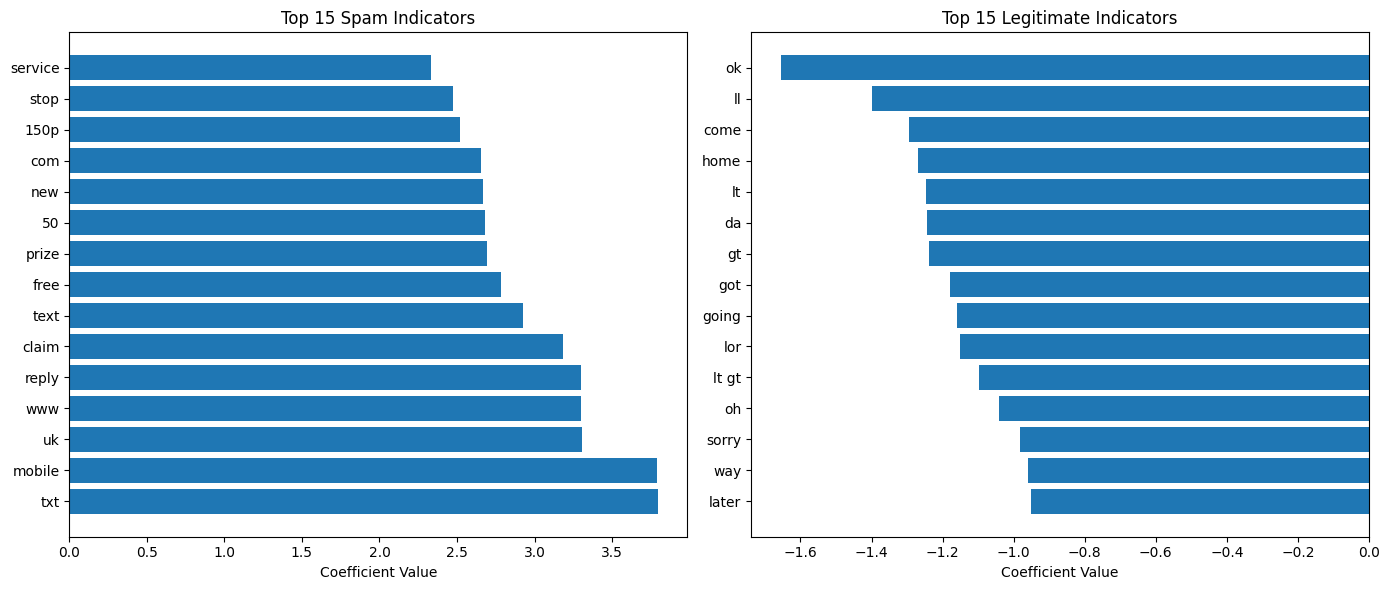

In [28]:
# Get feature importance from Logistic Regression
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = lr_model.coef_[0]

# Top 15 spam indicators (highest coefficients)
top_spam_idx = np.argsort(coefficients)[-15:]
top_spam_features = feature_names[top_spam_idx]
top_spam_coef = coefficients[top_spam_idx]

print("="*70)
print("TOP 15 SPAM INDICATORS (Logistic Regression)")
print("="*70)
for i, (feature, coef) in enumerate(zip(reversed(top_spam_features), reversed(top_spam_coef)), 1):
    print(f"{i:2d}. {feature:25s} (Coefficient: {coef:+.4f})")

# Top 15 legitimate indicators (lowest coefficients)
top_legit_idx = np.argsort(coefficients)[:15]
top_legit_features = feature_names[top_legit_idx]
top_legit_coef = coefficients[top_legit_idx]

print("\n" + "="*70)
print("TOP 15 LEGITIMATE INDICATORS (Logistic Regression)")
print("="*70)
for i, (feature, coef) in enumerate(zip(top_legit_features, top_legit_coef), 1):
    print(f"{i:2d}. {feature:25s} (Coefficient: {coef:+.4f})")

# Visualize top features
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Top spam features
ax1.barh(range(15), top_spam_coef)
ax1.set_yticks(range(15))
ax1.set_yticklabels(top_spam_features)
ax1.set_xlabel('Coefficient Value')
ax1.set_title('Top 15 Spam Indicators')
ax1.invert_yaxis()

# Top legitimate features
ax2.barh(range(15), top_legit_coef)
ax2.set_yticks(range(15))
ax2.set_yticklabels(top_legit_features)
ax2.set_xlabel('Coefficient Value')
ax2.set_title('Top 15 Legitimate Indicators')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

HYPERPARAMETER TUNING (BONUS)

In [29]:
# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

print("Tuning Logistic Regression Parameters...")

# Define parameters to try
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'max_iter': [1000]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,           # 5-fold cross-validation
    scoring='f1',   # Optimize for F1-score
    n_jobs=-1       # Use all processors
)

# Fit the grid search
grid_search.fit(X_train, y_train)

print("✅ Grid Search Complete!")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_tuned_model = grid_search.best_estimator_
tuned_pred = best_tuned_model.predict(X_test)
tuned_f1 = f1_score(y_test, tuned_pred)

print(f"Test Set F1-Score: {tuned_f1:.4f}")

Tuning Logistic Regression Parameters...
✅ Grid Search Complete!
Best Parameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2'}
Best CV F1-Score: 0.9155
Test Set F1-Score: 0.9143


CROSS-VALIDATION ANALYSIS

CROSS-VALIDATION ANALYSIS (5-Fold)

Naive Bayes:
  CV Scores: ['0.8508', '0.8817', '0.8525', '0.9231', '0.9286']
  Mean: 0.8873
  Std Dev: 0.0333

Logistic Regression:
  CV Scores: ['0.7394', '0.7674', '0.7349', '0.8045', '0.7955']
  Mean: 0.7683
  Std Dev: 0.0283

Support Vector Machine:
  CV Scores: ['0.9082', '0.9146', '0.9175', '0.9353', '0.9608']
  Mean: 0.9273
  Std Dev: 0.0190


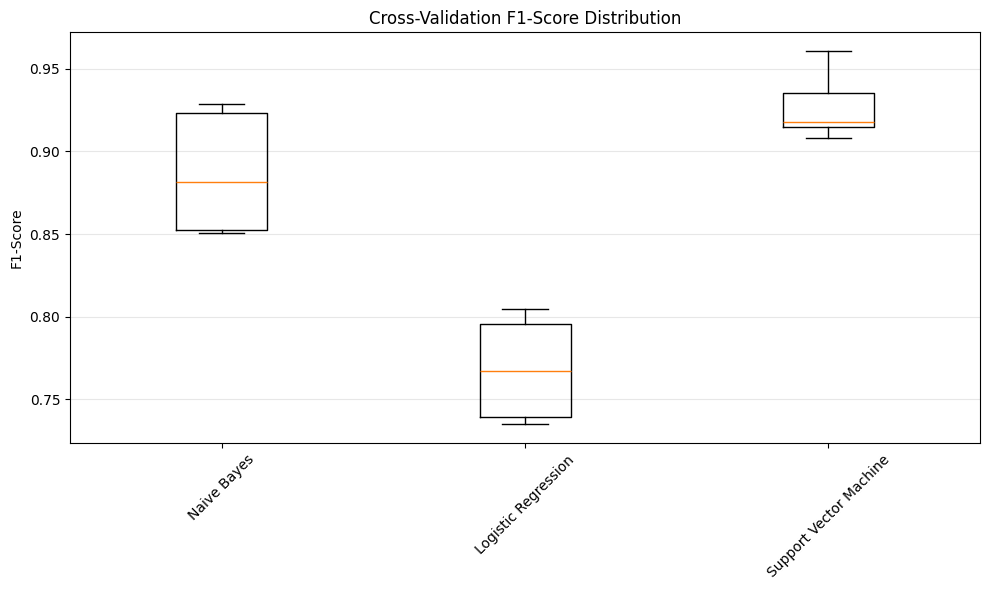

In [30]:
# Perform cross-validation on all models
from sklearn.model_selection import cross_val_score

print("="*70)
print("CROSS-VALIDATION ANALYSIS (5-Fold)")
print("="*70)

models_dict = {
    'Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
    'Support Vector Machine': svm_model
}

cv_results = {}

for name, model in models_dict.items():
    # Get cross-validation scores
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=5,           # 5-fold
        scoring='f1'    # Use F1-score
    )

    cv_results[name] = cv_scores

    print(f"\n{name}:")
    print(f"  CV Scores: {[f'{s:.4f}' for s in cv_scores]}")
    print(f"  Mean: {cv_scores.mean():.4f}")
    print(f"  Std Dev: {cv_scores.std():.4f}")

# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))
cv_data = [cv_results[name] for name in models_dict.keys()]
ax.boxplot(cv_data, labels=models_dict.keys())
ax.set_ylabel('F1-Score')
ax.set_title('Cross-Validation F1-Score Distribution')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 SAVE & LOAD MODELS

In [31]:
import pickle

# Save the best model
with open('spam_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model and Vectorizer saved!")

# -----------------------------------------------
# Load the saved model (in a new session)
# -----------------------------------------------

with open('spam_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_vectorizer = pickle.load(f)

# Test loaded model
test_msg = "Free money now!"
test_vector = loaded_vectorizer.transform([test_msg])
prediction = loaded_model.predict(test_vector)[0]
probability = loaded_model.predict_proba(test_vector)[0]

print(f"\nLoaded Model Test:")
print(f"Message: {test_msg}")
print(f"Prediction: {'SPAM' if prediction == 1 else 'LEGITIMATE'}")
print(f"Spam Probability: {probability[1]:.2%}")

✅ Model and Vectorizer saved!

Loaded Model Test:
Message: Free money now!
Prediction: LEGITIMATE
Spam Probability: 6.15%


 ADJUST PREDICTION THRESHOLD

In [32]:
# By default, prediction threshold is 0.5
# You can adjust it to catch more spam or reduce false positives

def predict_with_custom_threshold(message, model, vectorizer, threshold=0.5):
    """
    Predict with custom threshold
    threshold = 0.5 (default) : normal
    threshold = 0.3 (lower)   : catch more spam
    threshold = 0.7 (higher)  : fewer false positives
    """
    message_vector = vectorizer.transform([message])
    spam_probability = model.predict_proba(message_vector)[0][1]

    return {
        'message': message,
        'is_spam': spam_probability >= threshold,
        'probability': spam_probability
    }

# Test different thresholds
test_message = "Congratulations! You won a prize. Click here."

print("Testing Different Thresholds:")
print("-" * 70)

for threshold in [0.3, 0.5, 0.7]:
    result = predict_with_custom_threshold(
        test_message, best_model, tfidf, threshold=threshold
    )
    prediction = "SPAM" if result['is_spam'] else "LEGITIMATE"
    print(f"Threshold {threshold}: {prediction} (Probability: {result['probability']:.2%})")

Testing Different Thresholds:
----------------------------------------------------------------------
Threshold 0.3: SPAM (Probability: 95.51%)
Threshold 0.5: SPAM (Probability: 95.51%)
Threshold 0.7: SPAM (Probability: 95.51%)


PERFORMANCE SUMMARY REPORT

In [33]:
# Generate comprehensive summary report
print("\n" + "="*80)
print("COMPREHENSIVE PERFORMANCE SUMMARY REPORT")
print("="*80)

summary_report = f"""
Dataset Information:
  • Total messages: {len(df)}
  • Spam messages: {(df['label'] == 1).sum()} ({(df['label'] == 1).sum()/len(df)*100:.2f}%)
  • Legitimate messages: {(df['label'] == 0).sum()} ({(df['label'] == 0).sum()/len(df)*100:.2f}%)
  • Training set: {X_train.shape[0]} messages
  • Test set: {X_test.shape[0]} messages

Feature Extraction:
  • Vectorization Method: TF-IDF
  • Total features: {X.shape[1]}
  • N-gram range: (1, 2) [Unigrams + Bigrams]
  • Max features: 3000

Models Trained:
  1. Naive Bayes
  2. Logistic Regression
  3. Support Vector Machine (SVM)

BEST MODEL: {best_f1_model}
  • Accuracy:  {results[best_f1_model]['Accuracy']:.4f}
  • Precision: {results[best_f1_model]['Precision']:.4f}
  • Recall:    {results[best_f1_model]['Recall']:.4f}
  • F1-Score:  {results[best_f1_model]['F1-Score']:.4f}

Model Comparison:
"""

for model_name, metrics in results.items():
    summary_report += f"\n  {model_name}:"
    summary_report += f"\n    Accuracy:  {metrics['Accuracy']:.4f}"
    summary_report += f"\n    Precision: {metrics['Precision']:.4f}"
    summary_report += f"\n    Recall:    {metrics['Recall']:.4f}"
    summary_report += f"\n    F1-Score:  {metrics['F1-Score']:.4f}"

print(summary_report)
print("="*80)


COMPREHENSIVE PERFORMANCE SUMMARY REPORT

Dataset Information:
  • Total messages: 5169
  • Spam messages: 653 (12.63%)
  • Legitimate messages: 4516 (87.37%)
  • Training set: 4135 messages
  • Test set: 1034 messages

Feature Extraction:
  • Vectorization Method: TF-IDF
  • Total features: 3000
  • N-gram range: (1, 2) [Unigrams + Bigrams]
  • Max features: 3000

Models Trained:
  1. Naive Bayes
  2. Logistic Regression  
  3. Support Vector Machine (SVM)

BEST MODEL: SVM
  • Accuracy:  0.9797
  • Precision: 0.9825
  • Recall:    0.8550
  • F1-Score:  0.9143

Model Comparison:

  Naive Bayes:
    Accuracy:  0.9749
    Precision: 0.9907
    Recall:    0.8092
    F1-Score:  0.8908
  Logistic Regression:
    Accuracy:  0.9545
    Precision: 0.9884
    Recall:    0.6489
    F1-Score:  0.7834
  SVM:
    Accuracy:  0.9797
    Precision: 0.9825
    Recall:    0.8550
    F1-Score:  0.9143
